# Movie Recommendation Clustering
In this notebook, we will build a machine learning pipeline to group movies into clusters based on their genres, rating, and popularity.

### Step 1: Import Libraries
First, we need to import the necessary tools. 
- `pandas` and `numpy`: For handling the data table and numbers.
- `matplotlib` and `seaborn`: For drawing graphs and charts.
- `scikit-learn`: For the machine learning algorithms (clustering, scaling, etc.).

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MultiLabelBinarizer
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import ast
import os
import warnings
warnings.filterwarnings('ignore')

### Step 2: Load Dataset
Next, we load the Kaggle dataset `movies_metadata.csv`. 
We use `pandas` to read the CSV file, and then we preview the first 5 rows to see what the data looks like. We also check for any missing values.

In [3]:
file_path = 'movies_metadata.csv'

if not os.path.exists(file_path):
    print("Dataset not found. Please place 'movies_metadata.csv' in the same folder.")
else:
    # Load the data
    df = pd.read_csv(file_path, low_memory=False)
    
    print("First 5 rows of the dataset:")
    display(df.head())
    
    print("\nMissing values before cleaning:")
    print(df[['genres', 'vote_average', 'popularity']].isna().sum())

First 5 rows of the dataset:


,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0



Missing values before cleaning:
genres          0
vote_average    6
popularity      5
dtype: int64


### Step 3: Feature Extraction & Step 4: Genre Processing
The genres in the dataset are stored as a text representation of a list of dictionaries (like a JSON object). 
We need to write a little function using `ast.literal_eval` to safely parse that text and grab only the genre names (like \"Action\", \"Comedy\").

Then, we use `MultiLabelBinarizer` to convert those a list of words into \"binary columns\" (1 if the movie is that genre, 0 if not).

In [4]:
features = ['original_title', 'genres', 'vote_average', 'popularity']
df_features = df[features].copy()

# Function to safely parse the genre text and grab names
def extract_genres(genre_str):
    try:
        genre_list = ast.literal_eval(genre_str)
        return [g['name'] for g in genre_list]
    except:
        return []

df_features['genre_list'] = df_features['genres'].apply(extract_genres)

# Convert lists into binary grid (0s and 1s)
mlb = MultiLabelBinarizer()
genre_encoded = pd.DataFrame(mlb.fit_transform(df_features['genre_list']),
                             columns=mlb.classes_,
                             index=df_features.index)

print(f"Extracted {len(mlb.classes_)} unique genres.")

Extracted 32 unique genres.


### Step 5: Data Cleaning
Now we combine our extracted features back together.
We need to make sure `popularity` is recognized as a number, and then we throw away any rows that are missing important ratings or popularity data.

Because advanced algorithms (like hierarchical clustering and t-SNE) can be very slow when there are over 40,000 movies, we will pick a representative random sample of 5,000 movies.

In [5]:
# Convert popularity to numbers
df_features['popularity'] = pd.to_numeric(df_features['popularity'], errors='coerce')

# Combine our columns into a finalized table
df_modeling = pd.concat([df_features[['original_title', 'vote_average', 'popularity']], genre_encoded], axis=1)

# Drop rows with missing values
df_modeling.dropna(subset=['vote_average', 'popularity'], inplace=True)
print(f"Dataset shape after cleaning: {df_modeling.shape}")

# Sampling for efficiency
SAMPLE_SIZE = 5000
if len(df_modeling) > SAMPLE_SIZE:
    df_sample = df_modeling.sample(n=SAMPLE_SIZE, random_state=42).copy()
else:
    df_sample = df_modeling.copy()

# X is our data table meant purely for the machine learning model (no names)
X = df_sample.drop(columns=['original_title'])

Dataset shape after cleaning: (45460, 35)


### Step 6: Feature Scaling
In machine learning, \"Scaling\" is required before clustering.
Because \"Popularity\" could be a large number (like 100), but \"Rating\" is small (1 to 10), the model would think Popularity is the only thing that matters.
Scaling forces all columns to behave like they have equal importance.

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Data scaling complete.")

Data scaling complete.


### Step 7: Clustering Models
Now we group the movies! We will ask the computer to find `5` different groups.

- **KMeans**: Try to put movies in bubbles around a central point.
- **Hierarchical (Agglomerative)**: Try to build a tree of similarity and chop the tree into 5 branches.

In [7]:
n_clusters = 5

# 1. KMeans Clustering
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)
df_sample['Cluster_KMeans'] = kmeans_labels

# 2. Hierarchical Clustering
agg_cluster = AgglomerativeClustering(n_clusters=n_clusters)
agg_labels = agg_cluster.fit_predict(X_scaled)
df_sample['Cluster_Hierarchical'] = agg_labels

print("Finished predicting clusters.")

Finished predicting clusters.


### Step 8: Cluster Evaluation
Did the algorithm do a good job?
The **Silhouette Score** measures how tight and separated the groups are. A score closer to 1 means excellent separation. A score near 0 means overlapping clusters.

In [8]:
kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)
agg_silhouette = silhouette_score(X_scaled, agg_labels)

print(f"KMeans Silhouette Score: {kmeans_silhouette:.4f}")
print(f"Hierarchical Silhouette Score: {agg_silhouette:.4f}")

KMeans Silhouette Score: 0.1847
Hierarchical Silhouette Score: 0.1660


### Step 9: Dimensionality Reduction
Currently, our table has many columns (Rating, Popularity, and 30+ genres). Humans can only see in 2D or 3D.
\"Dimensionality Reduction\" forcefully crushes down those 35 columns into just 2 columns (X and Y coordinates) so we can place them on a flat graph.

- **PCA**: A strict geometric squish.
- **t-SNE**: A flexible mapping that preserves neighbor relationships (takes longer but looks better).

In [9]:
print("Computing PCA...")
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
df_sample['PCA1'] = X_pca[:, 0]
df_sample['PCA2'] = X_pca[:, 1]

print("Computing t-SNE... (this takes a moment)")
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)
df_sample['TSNE1'] = X_tsne[:, 0]
df_sample['TSNE2'] = X_tsne[:, 1]
print("Dimensionality reduction complete.")

Computing PCA...
Computing t-SNE... (this takes a moment)
Dimensionality reduction complete.


### Step 10: Visualization
We will draw 4 different charts to show how well our groups separated when they were crushed down into 2D space.

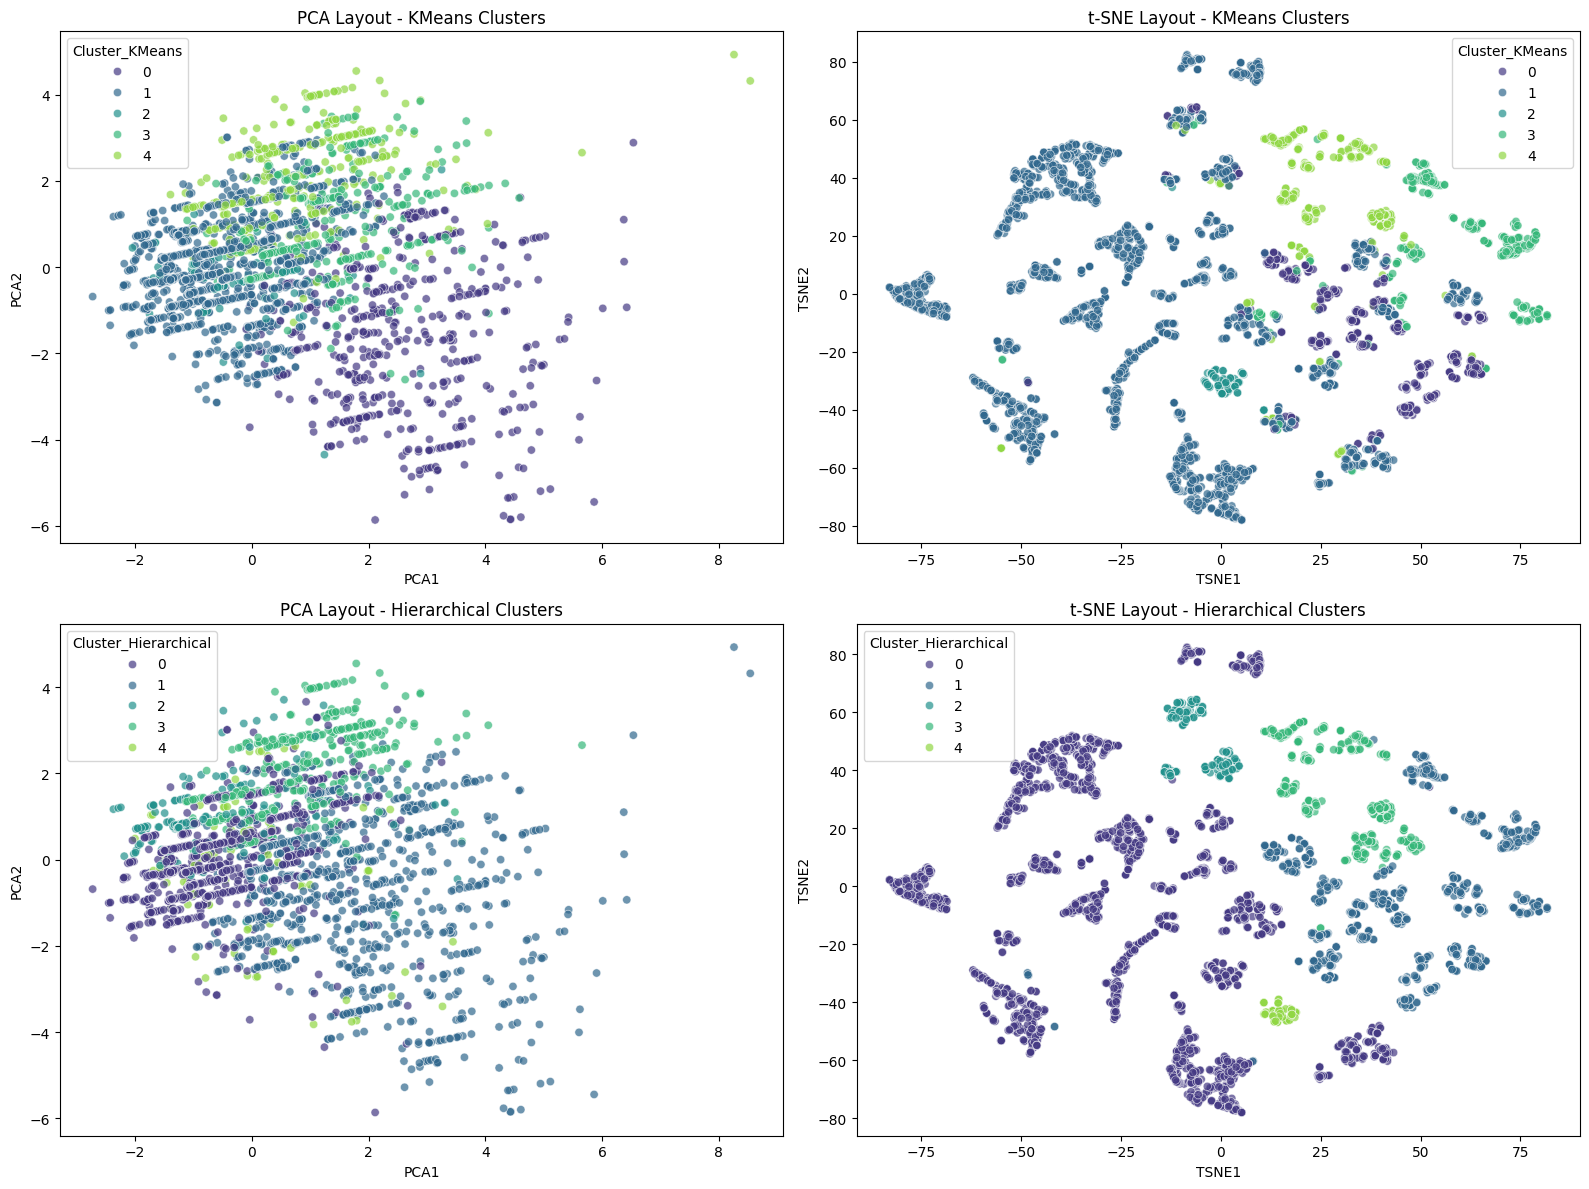

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
# Choose a beautiful color palette from Seaborn
palette = sns.color_palette("viridis", n_clusters)

sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster_KMeans', data=df_sample, ax=axes[0, 0], palette=palette, alpha=0.7)
axes[0, 0].set_title('PCA Layout - KMeans Clusters')

sns.scatterplot(x='TSNE1', y='TSNE2', hue='Cluster_KMeans', data=df_sample, ax=axes[0, 1], palette=palette, alpha=0.7)
axes[0, 1].set_title('t-SNE Layout - KMeans Clusters')

sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster_Hierarchical', data=df_sample, ax=axes[1, 0], palette=palette, alpha=0.7)
axes[1, 0].set_title('PCA Layout - Hierarchical Clusters')

sns.scatterplot(x='TSNE1', y='TSNE2', hue='Cluster_Hierarchical', data=df_sample, ax=axes[1, 1], palette=palette, alpha=0.7)
axes[1, 1].set_title('t-SNE Layout - Hierarchical Clusters')

plt.tight_layout()
plt.show()

### Step 11: Insights
Finally, let's look at what actually defines these clusters! We will calculate the average rating, the average popularity, and the top genres for each cluster.

In [11]:
df_sample['Cluster_KMeans'] = df_sample['Cluster_KMeans'].astype(int)

# Calculate basic averages
cluster_summary = df_sample.groupby('Cluster_KMeans')[['vote_average', 'popularity']].mean()
cluster_summary['movie_count'] = df_sample['Cluster_KMeans'].value_counts().sort_index()

print("Cluster Profile:")
display(cluster_summary)

print("\nTop Genres per Cluster:")
genre_freq = df_sample.groupby('Cluster_KMeans')[mlb.classes_].mean()

for cluster_id, row in genre_freq.iterrows():
    top_genres = row.nlargest(3).index.tolist()
    freqs = [f"{val*100:.1f}%" for val in row.nlargest(3).values]
    top_genres_str = ", ".join([f"{g} ({f})" for g, f in zip(top_genres, freqs)])
    print(f"Cluster {cluster_id}: {top_genres_str}")

Cluster Profile:


,vote_average,popularity,movie_count
Cluster_KMeans,,,
0,5.729881,4.997831,589
1,5.644098,2.180298,3372
2,4.834234,1.994558,111
3,5.187474,3.543178,479
4,5.971492,4.822387,449



Top Genres per Cluster:
Cluster 0: Adventure (51.3%), Action (41.9%), Animation (37.2%)
Cluster 1: Drama (51.1%), Comedy (34.3%), Romance (19.4%)
Cluster 2: Western (100.0%), Action (27.0%), Drama (24.3%)
Cluster 3: Horror (99.4%), Thriller (40.1%), Science Fiction (20.0%)
Cluster 4: Crime (99.3%), Drama (64.1%), Thriller (45.4%)
